# 딥러닝-회귀 모델링

Boston Housing 데이터를 사용해 PyTorch 기반 DNN 회귀 모델을 만들고 비교합니다.

이 노트북의 목표는 다음과 같습니다.

- pandas/numpy 데이터를 PyTorch `DataLoader`와 텐서로 변환한다.
- 미니배치 학습 함수와 검증 함수를 재사용한다.
- 입력 변수 수와 은닉층 구조를 바꾸며 회귀 성능을 비교한다.
- MSE, RMSE, MAE, MAPE로 모델을 평가한다.

## 1. 환경 준비

필요한 라이브러리를 불러오고, 반복해서 사용할 함수들을 먼저 정의합니다.

### 1.1 라이브러리 불러오기

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [30]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### 1.2 필요 함수 생성

아래 3개 함수가 학습 흐름의 핵심입니다.

- `make_DataSet`: 학습 데이터는 `DataLoader`로 만들고, 검증 데이터는 텐서로 변환합니다.
- `train`: 한 epoch 동안 미니배치 학습을 수행합니다.
- `evaluate`: 검증 데이터 전체에 대해 손실과 예측값을 반환합니다.

- `make_DataSet` 함수 : 딥러닝을 위한 데이터로더 만들기

In [31]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """    pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

- `train` 함수 : 학습을 위한 함수

In [32]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (X, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결

        # Feed Forward
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지. 한 배치를 시작할 때 이전 배치의 gradient를 먼저 지우고, 현재 배치의 gradient만 계산
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()         # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()        # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)       # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적


    return total_loss / len(dataloader.dataset)     # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

- `evauate` 함수 : 검증을 위한 함수

In [33]:

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()         # 모델을 평가 모드로 설정

    with torch.no_grad():       # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

- 학습 곡선

In [34]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


## 2. 데이터 준비

Boston Housing 데이터는 타운별 주택 가격 중위값(`medv`)을 예측하는 회귀 데이터입니다.


|	변수	|	설명	|
|	----	|	----	|
|	medv	|	타운별 집값(중위수)	|
|	crim	|	범죄율	|
|	zn	|	25,000 평방피트를 초과 거주지역 비율	|
|	indus	|	비소매상업지역 면적 비율	|
|	chas	|	찰스강변 위치(범주 : 강변1, 아니면 0)	|
|	nox	|	일산화질소 농도	|
|	rm	|	주택당 방 수	|
|	age	|	1940년 이전에 건축된 주택의 비율	|
|	dis	|	직업센터의 거리	|
|	rad	|	방사형 고속도로까지의 거리	|
|	tax	|	재산세율	|
|	ptratio	|	학생/교사 비율	|
|	lstat	|	인구 중 하위 계층 비율	|


In [36]:
path = 'dataset/boston.csv'
df = pd.read_csv(path)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [39]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


## 3. 모델링 1: 주요 변수 3개로 선형 모델 만들기

먼저 `lstat`, `ptratio`, `crim` 3개 변수만 사용합니다. 모델은 입력층과 출력층만 있는 가장 단순한 선형 회귀 구조입니다.

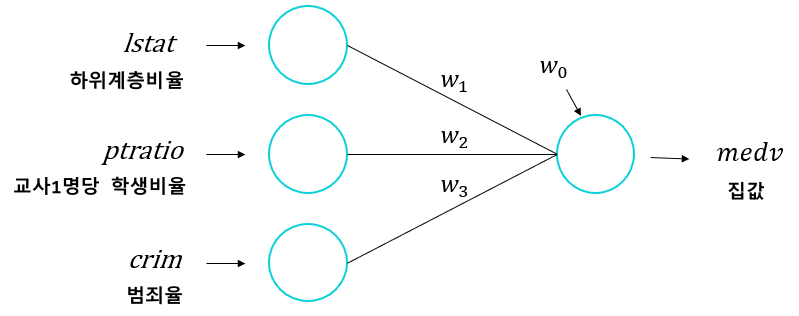

### 3.1 데이터 전처리

- X, y 나누기
    - X : lstat, ptratio, crim
    - y : medv

In [40]:
target = 'medv'
features = ['lstat', 'ptratio', 'crim']
X = df.loc[:, features]
y = df[target]

- 데이터 분할

In [41]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=2026)

- 스케일링

In [42]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### 3.2 딥러닝을 위한 준비작업
- make_DataLoader
    - train : 미니 배치 처리를 위한 데이터 로더로 만들기
    - val : 검증셋으로 성능 측정하면 되므로 텐서 그대로 사용

In [43]:
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val, batch_size=32)
# 특별한 경우가 아니면 보통 32(기본값), 데이터가 많으면 32보다 크게(학습 데이터)

In [44]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(x.shape)
    print(y.shape, y.dtype)
    break

torch.Size([32, 3])
torch.Size([32, 1]) torch.float32


### 3.3 모델 선언
- nn.Linear(입력, 출력) 레이어 한개 추가
    - [출력] 층의 **노드 수**

In [60]:
X.shape[1]

13

In [61]:
n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 1)
).to(device)

print(model1)

Sequential(
  (0): Linear(in_features=13, out_features=1, bias=True)
)


- Loss function과 Optimizer
    - loss function : MSE
    - Optimizer : Adam(모델 파라미터, 학습률)

In [53]:
loss_fn = nn.MSELoss()
optimizer = Adam(model1.parameters(), lr=0.01) # learning rate

### 3.4 모델 학습

In [ ]:
epochs = 200 # 학습 횟수
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

- 학습된 파라미터 확인
    - 모델이 학습한 가중치를 확인하면 각 입력 변수가 예측값에 어떤 방향으로 기여하는지 대략적으로 볼 수 있습니다.
    - 단, 입력값을 스케일링했기 때문에 원래 단위의 계수와 직접 비교하면 안 됩니다.

In [49]:
for name, param in model1.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[ 2.0942,  9.6238, -8.8551]])
Parameter: 0.bias, Value: tensor([14.3414])


- 학습 곡선

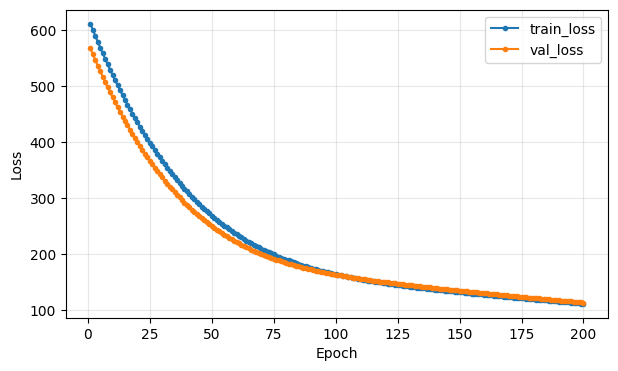

In [50]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 3.5 모델 평가

In [54]:
loss, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

- 평가 추가 : MAE, MAPE

In [55]:
mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MAE:{mae}')
print(f'MAPE:{mape}')

MAE:7.570812225341797
MAPE:0.4293304979801178


## 4. 모델링 2: 전체 변수로 선형 모델 만들기

- 이제 `medv`를 제외한 모든 변수를 사용합니다. 모델 구조는 여전히 선형 모델입니다.

### 4.1 데이터 전처리

- 데이터 분할

In [63]:
target = 'medv'
X = df.drop(target, axis=1)
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=2026)

- 스케일링

In [64]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### 4.2 모델링

- make_DataLoader

In [65]:
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val)

- 모델 설계

In [66]:
X.shape

(506, 12)

In [67]:
n_feature = X.shape[1]

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Linear(n_feature, 1)
).to(device)

print(model2)

Sequential(
  (0): Linear(in_features=12, out_features=1, bias=True)
)


- Loss function과 Optimizer

In [69]:
loss_fn = nn.MSELoss()
optimizer = Adam(model2.parameters(), lr=0.01) # learning rate

### 4.3 모델 학습

In [ ]:
epochs = 100 # 학습 횟수
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

- 학습된 파라미터 확인

In [71]:
for name, param in model2.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-6.3329,  8.1706,  2.3558,  5.4840,  2.2564,  7.2535,  4.3577,  7.7171,
          0.1440,  0.9225,  4.3105,  0.1630]])
Parameter: 0.bias, Value: tensor([6.4293])


- 학습 곡선

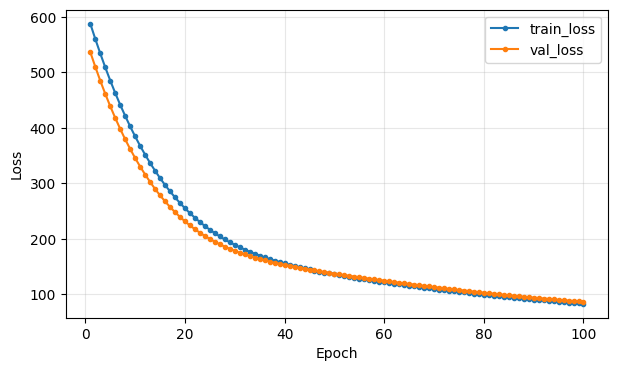

In [72]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 4.4 모델 평가

In [73]:
loss, pred = evaluate(X_val_ts, y_val_ts, model2, loss_fn, device)

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 86.52782440185547
MAE : 6.909537315368652
MAPE : 0.4022107720375061


## 5. 모델링 3: 은닉층 추가
- 데이터 전처리와 모델링은 `4. 모델링2`에서 준비한 데이터와 선언한 DataLoader를 그대로 사용

### 5.1 데이터 전처리
- `4.모델링2`에서 준비한 데이터 그대로 이용

### 5.2 모델링
- `4.모델링2` 에서 선언한 DataLoader를 그대로 사용


- 모델 설계

In [74]:
n_feature = X.shape[1]

# 모델 구조 설계
model3 = nn.Sequential(
    nn.Linear(n_feature, 4),    # input : 12, output : 2
    nn.ReLU(),                  # 활성화 함수
    nn.Linear(4, 1)             # output layer
    ).to(device)

print(model3)

Sequential(
  (0): Linear(in_features=12, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)


- Loss function과 Optimizer

In [75]:
loss_fn = nn.MSELoss()
optimizer = Adam(model3.parameters(), lr=0.01)

### 5.3 모델 학습

In [ ]:
epochs = 200
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model3, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

- 학습된 파라미터 확인

In [77]:
for name, param in model3.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-1.1559e+00,  1.0463e+00,  1.9705e-01,  4.1884e-01, -8.1987e-01,
          6.2991e+00,  6.5339e-01, -1.9165e+00,  1.0604e+00, -1.3910e+00,
         -1.6005e+00, -5.9538e+00],
        [-2.7857e-05, -2.9934e-01,  7.1039e-02, -6.9675e-02,  3.9254e-02,
         -1.2077e-01, -3.1176e-01,  6.7007e-02,  6.2595e-02, -3.1792e-01,
          1.8634e-02,  5.8603e-02],
        [ 1.0514e-02, -5.3429e-02,  5.1969e-02, -1.2065e-01, -2.9155e-01,
         -7.2912e-02, -3.0210e-02, -1.5830e-01,  5.8453e-02, -2.9214e-01,
          7.3966e-02, -3.4006e-01],
        [-1.5084e-01, -3.4133e-01, -2.2901e-01, -2.0659e-01, -1.1238e-01,
         -2.8017e-02, -1.2970e-01,  1.0394e-01, -1.2209e-01, -2.5817e-02,
         -1.9081e-01, -3.5691e-01]])
Parameter: 0.bias, Value: tensor([ 4.7964e+00, -1.6876e-01, -7.3802e-02,  4.3018e-03])
Parameter: 2.weight, Value: tensor([[ 3.9732, -0.3046, -0.2493, -0.2784]])
Parameter: 2.bias, Value: tensor([2.5132])


- 학습 곡선

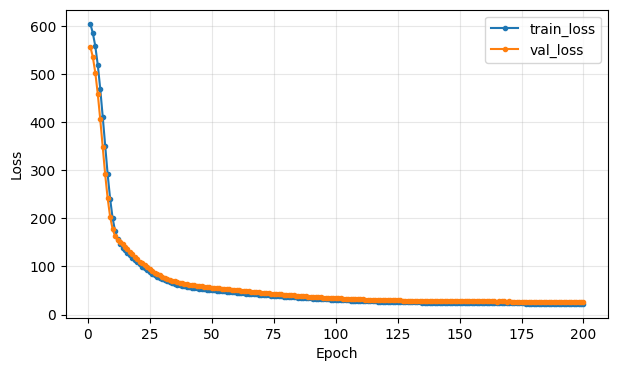

In [79]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 5.4 모델 평가

In [80]:
loss, pred = evaluate(X_val_ts, y_val_ts, model3, loss_fn, device)

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 26.676557540893555
MAE : 3.662325143814087
MAPE : 0.20035023987293243


## **6. 연습문제1**

- 다음의 모델 구조대로 모델링을 수행하고 성능평가를 해 봅시다.
    - 모델 구조

            Sequential(
                (0): Linear(in_features=12, out_features=8, bias=True)
                (1): ReLU()
                (2): Linear(in_features=8, out_features=5, bias=True)
                (3): ReLU()
                (4): Linear(in_features=5, out_features=1, bias=True)
            )
    - epochs(반복횟수) : 100
    - lr(learning rate, 학습률) : 0.01

- Boston 데이터는 크기가 작기 때문에 모델을 무조건 크게 만든다고 성능이 좋아지지는 않습니다.
- 학습 곡선에서 train loss와 validation loss의 차이를 함께 확인합니다.

- 모델 설계

In [81]:
n_feature = X.shape[1]

# 모델 구조 설계
model4 = nn.Sequential(
    nn.Linear(n_feature, 8),    # input : 12, output : 8
    nn.ReLU(),                  # 활성화 함수
    nn.Linear(8, 5),             # input : 8, output : 5
    nn.ReLU(),                  # 활성화 함수
    nn.Linear(5, 1)             # output layer
    ).to(device)

print(model4)

Sequential(
  (0): Linear(in_features=12, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
)


- Loss function과 Optimizer

In [82]:
loss_fn = nn.MSELoss()
optimizer = Adam(model4.parameters(), lr=0.01)

- 모델 학습

In [ ]:
epochs = 100 # 학습 횟수
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model4, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model4, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

- 학습 곡선

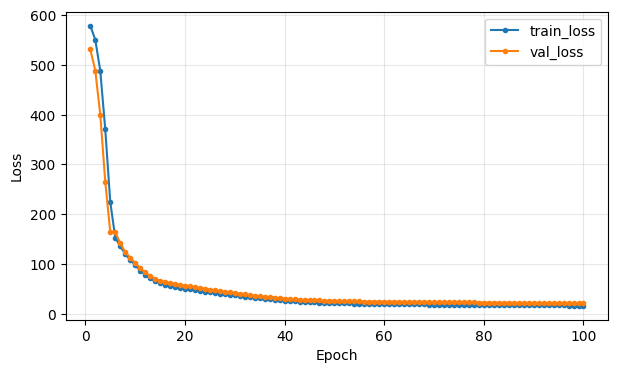

In [84]:
dl_learning_curve(tr_loss_list, val_loss_list)

- 모델 평가 : MSE

In [85]:
loss, pred = evaluate(X_val_ts, y_val_ts, model4, loss_fn, device)

In [86]:
mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 21.072866439819336
MAE : 3.1888227462768555
MAPE : 0.18375834822654724


## **7. 연습문제2**
* 여러분이 원하는 구조와 하이퍼파라미터 값을 조정하여 성능을 높여 봅시다.
- 수정해 볼 만한 항목은 다음과 같습니다.

    - 은닉층 노드 수: `16`, `32`, `64`
    - 은닉층 개수
    - 학습률: `0.001`, `0.005`, `0.01`
    - epoch 수
    - batch size

- 모델 설계

In [89]:
n_feature = X.shape[1]

# 모델 구조 설계 (연습문제2)
model5 = nn.Sequential(
    nn.Linear(n_feature, 64), # input: 12, output: 64
    nn.ReLU(),                # 활성화 함수
    nn.Linear(64, 32),        # input: 64, output: 32
    nn.ReLU(),                # 활성화 함수
    nn.Linear(32, 16),        # input: 32, output: 16
    nn.ReLU(),                # 활성화 함수
    nn.Linear(16, 1)          # output layer
).to(device)

print(model5)

Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
)


- Loss function과 Optimizer

In [90]:
loss_fn = nn.MSELoss()
optimizer = Adam(model5.parameters(), lr=0.005) # Learning rate adjusted

- 모델 학습

In [91]:
epochs = 150 # 학습 횟수 조정
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model5, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model5, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 586.079668, val loss : 522.249451
Epoch 2, train loss : 469.755910, val loss : 260.004395
Epoch 3, train loss : 203.980122, val loss : 187.601425
Epoch 4, train loss : 127.786762, val loss : 119.203125
Epoch 5, train loss : 97.939697, val loss : 101.490417
Epoch 6, train loss : 75.418151, val loss : 74.838135
Epoch 7, train loss : 61.605609, val loss : 65.580521
Epoch 8, train loss : 54.501007, val loss : 59.988060
Epoch 9, train loss : 50.181919, val loss : 55.368809
Epoch 10, train loss : 46.192921, val loss : 51.025879
Epoch 11, train loss : 43.002990, val loss : 46.171700
Epoch 12, train loss : 38.295823, val loss : 43.578087
Epoch 13, train loss : 35.181042, val loss : 38.908539
Epoch 14, train loss : 31.211252, val loss : 34.575855
Epoch 15, train loss : 27.723728, val loss : 32.845936
Epoch 16, train loss : 26.819707, val loss : 28.952440
Epoch 17, train loss : 23.329230, val loss : 27.483322
Epoch 18, train loss : 21.879667, val loss : 26.476772
Epoch 19, 

- 학습 곡선

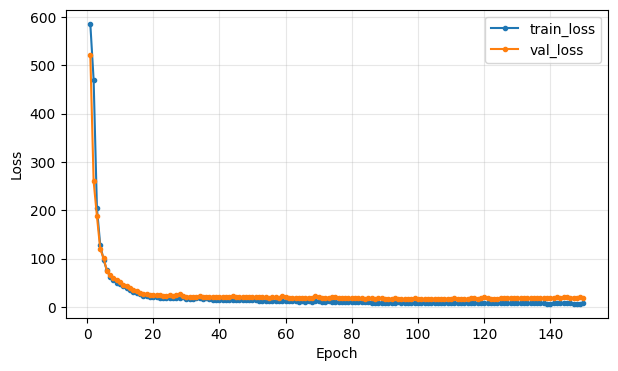

In [92]:
dl_learning_curve(tr_loss_list, val_loss_list)

- 모델 평가 : MSE

In [93]:
loss, pred = evaluate(X_val_ts, y_val_ts, model5, loss_fn, device)

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE (Exercise 2) : {loss}')
print(f'MAE (Exercise 2) : {mae}')
print(f'MAPE (Exercise 2) : {mape}')

MSE (Exercise 2) : 19.14253044128418
MAE (Exercise 2) : 2.8632287979125977
MAPE (Exercise 2) : 0.1657368689775467
